# UCF-101: 2D Baseline + R(2+1)D + Ablation


# Phase 0: Setup


In [ ]:
# Local hardware check (Apple Silicon does not have nvidia-smi)
import platform, subprocess
print('System:', platform.system(), platform.machine())
if platform.system() == 'Darwin':
    try:
        out = subprocess.run(['system_profiler', 'SPHardwareDataType'], capture_output=True, text=True).stdout
        for line in out.split('\n'):
            if any(k in line for k in ['Chip', 'Memory', 'Cores']):
                print(line.strip())
    except Exception:
        pass

System: Darwin arm64
Chip: Apple M1 Pro
Total Number of Cores: 10 (8 performance and 2 efficiency)
Memory: 16 GB


In [ ]:
# Local setup: install OpenCV instead of decord (decord doesn't have Apple Silicon wheels).
# If you've already installed everything in your venv, this is a no-op.
!pip install -q opencv-python tqdm

In [ ]:
import os, json, time, random, shutil
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models.video import r2plus1d_18, R2Plus1D_18_Weights
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# Use Apple Silicon GPU (MPS) if available, fall back to CPU.
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Using MPS (Apple Silicon GPU)')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('Using CUDA')
else:
    DEVICE = torch.device('cpu')
    print('Using CPU (warning: this will be slow)')
print('Device:', DEVICE)


Using MPS (Apple Silicon GPU)
Device: mps


In [ ]:
# Local mode: no Drive mount needed. The notebook reads from local paths set below.
# (Original Colab mount cell was here.)
import os
print('Running locally. UCF-101 is expected at the paths defined in the next cell.')

Running locally. UCF-101 is expected at the paths defined in the next cell.


In [ ]:
# === LOCAL PATHS: edit DATA_ROOT to point to where you extracted UCF-101 ===
DATA_ROOT   = os.path.dirname(os.path.abspath('ucf101_merged_local.ipynb'))  # project folder containing UCF-101/ and ucfTrainTestlist/
VIDEOS_DIR  = f'{DATA_ROOT}/Data/UCF-101'
SPLITS_DIR  = f'{DATA_ROOT}/Data/ucfTrainTestlist'
FRAMES_DIR  = f'{DATA_ROOT}/frames'
OUTPUT_DIR  = f'{DATA_ROOT}/outputs'
FIGURES_DIR = f'{OUTPUT_DIR}/figures'
CKPT_DIR    = f'{DATA_ROOT}/checkpoints'

for d in [FRAMES_DIR, OUTPUT_DIR, FIGURES_DIR, CKPT_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

# === Subset configuration (shared by both models for fair comparison) ===
USE_SUBSET = True
SUBSET_PER_CLASS = 30
VAL_GROUPS_PER_CLASS = 1
FRAMES_PER_VIDEO = 16   # extract this many; both models use them

# === 2D baseline hyperparameters ===
TWOD_IMG_SIZE   = 224
TWOD_BATCH      = 64
TWOD_EPOCHS     = 15
TWOD_LR         = 1e-3

# === R(2+1)D hyperparameters ===
R2D_IMG_SIZE    = 112   # matches Kinetics-pretrained weights
R2D_CLIP_LEN    = 16
R2D_BATCH       = 4     # MPS: smaller batch for unified memory
R2D_EPOCHS      = 15
R2D_LR          = 1e-3

# === Shared optimizer settings ===
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0  # macOS: single-process loading avoids worker hangs

print(f'Data root: {DATA_ROOT}')
print(f'Subset: {USE_SUBSET} ({SUBSET_PER_CLASS}/class) | Frames/video: {FRAMES_PER_VIDEO}')
print(f'2D:  ResNet-18 {TWOD_IMG_SIZE}x{TWOD_IMG_SIZE}, batch {TWOD_BATCH}, {TWOD_EPOCHS} epochs')
print(f'R2D: R(2+1)D-18 {R2D_CLIP_LEN}f@{R2D_IMG_SIZE}x{R2D_IMG_SIZE}, batch {R2D_BATCH}, {R2D_EPOCHS} epochs')


Data root: /Users/sikanderraheem/Documents/VideoActionRecognition
Subset: True (30/class) | Frames/video: 16
2D:  ResNet-18 224x224, batch 64, 15 epochs
R2D: R(2+1)D-18 16f@112x112, batch 4, 15 epochs


### Load splits and build train/val/test sets

Group-aware split: validation is one held-out recording group per class. Same subset for both models so the comparison is fair.

In [ ]:
def load_class_index(splits_dir):
    cls_path = Path(splits_dir) / 'classInd.txt'
    name_to_id = {}
    with open(cls_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                idx, name = parts
                name_to_id[name] = int(idx) - 1
    return name_to_id

def parse_split_file(path, name_to_id):
    items = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            rel = line.split()[0]
            class_name = rel.split('/')[0]
            label = name_to_id[class_name]
            fname = Path(rel).stem
            try:
                group = fname.split('_g')[1].split('_')[0]
            except Exception:
                group = '00'
            items.append((rel, label, group))
    return items

name_to_id = load_class_index(SPLITS_DIR)
id_to_name = {v: k for k, v in name_to_id.items()}
NUM_CLASSES = len(name_to_id)

train_items_full = parse_split_file(Path(SPLITS_DIR)/'trainlist01.txt', name_to_id)
test_items_full  = parse_split_file(Path(SPLITS_DIR)/'testlist01.txt',  name_to_id)

by_class = defaultdict(list)
for rel, label, group in train_items_full:
    by_class[label].append((rel, label, group))
train_items, val_items = [], []
for label, vids in by_class.items():
    groups_sorted = sorted(set(g for _, _, g in vids))
    val_groups = set(groups_sorted[:VAL_GROUPS_PER_CLASS])
    for rel, lab, g in vids:
        (val_items if g in val_groups else train_items).append((rel, lab, g))

test_items = test_items_full
if USE_SUBSET:
    by_label_train = defaultdict(list)
    for it in train_items: by_label_train[it[1]].append(it)
    train_items = []
    for label, vids in by_label_train.items():
        random.Random(SEED).shuffle(vids)
        train_items.extend(vids[:SUBSET_PER_CLASS])
    by_label_test = defaultdict(list)
    for it in test_items: by_label_test[it[1]].append(it)
    test_items = []
    for label, vids in by_label_test.items():
        random.Random(SEED).shuffle(vids)
        test_items.extend(vids[:10])

print(f'Classes: {NUM_CLASSES}')
print(f'Train: {len(train_items)} | Val: {len(val_items)} | Test: {len(test_items)}')

Classes: 101
Train: 3030 | Val: 528 | Test: 1010


### Frame extraction (once for both models)

In [ ]:
import cv2  # OpenCV: works reliably on Apple Silicon, unlike decord

def video_id(rel_path): return Path(rel_path).stem

def extract_frames(rel_path, n_frames, out_root, short_side=256):
    src = Path(VIDEOS_DIR) / rel_path
    out_dir = Path(out_root) / video_id(rel_path)
    if out_dir.exists() and len(list(out_dir.glob('*.jpg'))) >= n_frames:
        return True
    cap = cv2.VideoCapture(str(src))
    if not cap.isOpened():
        print('open fail:', src); return False
    L = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if L < 1:
        cap.release(); return False
    idxs = (np.linspace(0, L-1, n_frames).astype(int).tolist()
            if L >= n_frames else list(range(L)) + [L-1]*(n_frames-L))
    out_dir.mkdir(parents=True, exist_ok=True)
    frames = []
    for idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, fr = cap.read()
        if not ret:
            # Try fallback: rewind and step forward
            cap.set(cv2.CAP_PROP_POS_FRAMES, 0)
            for _ in range(idx + 1):
                ret, fr = cap.read()
                if not ret: break
        if ret:
            # OpenCV reads BGR; convert to RGB
            fr = cv2.cvtColor(fr, cv2.COLOR_BGR2RGB)
            frames.append(fr)
        else:
            # Fall back to duplicating the last good frame
            if frames:
                frames.append(frames[-1])
            else:
                cap.release(); return False
    cap.release()
    H, W = frames[0].shape[0], frames[0].shape[1]
    scale = short_side / min(H, W)
    new_h, new_w = int(round(H*scale)), int(round(W*scale))
    for j, fr in enumerate(frames):
        Image.fromarray(fr).resize((new_w,new_h), Image.BILINEAR).save(out_dir/f'frame_{j:02d}.jpg', quality=90)
    return True

all_items = train_items + val_items + test_items
print(f'Extracting (or verifying) frames for {len(all_items)} videos -> {FRAMES_DIR}')
t0 = time.time()
ok, fail = 0, 0
for rel, _, _ in tqdm(all_items):
    if extract_frames(rel, FRAMES_PER_VIDEO, FRAMES_DIR):
        ok += 1
    else:
        fail += 1
print(f'Done in {(time.time()-t0)/60:.1f} min. OK={ok} Failed={fail}')

Extracting (or verifying) frames for 4568 videos -> /Users/sikanderraheem/Documents/VideoActionRecognition/frames


  0%|          | 0/4568 [00:00<?, ?it/s]

Done in 4.9 min. OK=4568 Failed=0


# Phase 1: 2D Baseline (ResNet-18 frame averaging)


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf_2d = transforms.Compose([
    transforms.RandomResizedCrop(TWOD_IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_tf_2d = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(TWOD_IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class FrameTrainDataset2D(Dataset):
    def __init__(self, items, frames_root, tf, n_frames):
        self.items = [it for it in items if (Path(frames_root)/video_id(it[0])).exists()]
        self.frames_root = Path(frames_root); self.tf = tf; self.n_frames = n_frames
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        rel, label, _ = self.items[i]
        d = self.frames_root/video_id(rel)
        idx = random.randrange(self.n_frames)
        img = Image.open(d/f'frame_{idx:02d}.jpg').convert('RGB')
        return self.tf(img), label

class VideoTestDataset2D(Dataset):
    def __init__(self, items, frames_root, tf, n_frames):
        self.items = [it for it in items if (Path(frames_root)/video_id(it[0])).exists()]
        self.frames_root = Path(frames_root); self.tf = tf; self.n_frames = n_frames
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        rel, label, _ = self.items[i]
        d = self.frames_root/video_id(rel)
        frames = [self.tf(Image.open(d/f'frame_{j:02d}.jpg').convert('RGB'))
                  for j in range(self.n_frames)]
        return torch.stack(frames, 0), label, rel

train_ds_2d = FrameTrainDataset2D(train_items, FRAMES_DIR, train_tf_2d, FRAMES_PER_VIDEO)
val_ds_2d   = VideoTestDataset2D(val_items,   FRAMES_DIR, eval_tf_2d,  FRAMES_PER_VIDEO)
test_ds_2d  = VideoTestDataset2D(test_items,  FRAMES_DIR, eval_tf_2d,  FRAMES_PER_VIDEO)

train_loader_2d = DataLoader(train_ds_2d, batch_size=TWOD_BATCH, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader_2d   = DataLoader(val_ds_2d,  batch_size=8, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader_2d  = DataLoader(test_ds_2d, batch_size=8, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f'2D Train frames: {len(train_ds_2d)} | Val: {len(val_ds_2d)} | Test: {len(test_ds_2d)}')

2D Train frames: 3030 | Val: 528 | Test: 1010


In [ ]:
model_2d = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model_2d.fc = nn.Linear(model_2d.fc.in_features, NUM_CLASSES)
model_2d = model_2d.to(DEVICE)

criterion = nn.CrossEntropyLoss()
opt_2d = optim.SGD(model_2d.parameters(), lr=TWOD_LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
sch_2d = optim.lr_scheduler.MultiStepLR(opt_2d, milestones=[int(TWOD_EPOCHS*0.6), int(TWOD_EPOCHS*0.8)], gamma=0.1)
print(f'ResNet-18 ready. {sum(p.numel() for p in model_2d.parameters())/1e6:.2f}M params')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/sikanderraheem/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:07<00:00, 5.95MB/s]


ResNet-18 ready. 11.23M params


In [ ]:
@torch.no_grad()
def eval_2d(model, loader):
    model.eval()
    all_logits, all_labels, all_paths = [], [], []
    for frames, labels, paths in loader:
        B, T = frames.shape[0], frames.shape[1]
        flat = frames.view(B*T, *frames.shape[2:]).to(DEVICE, non_blocking=True)
        logits = model(flat).view(B, T, -1).softmax(-1).mean(1)
        all_logits.append(logits.cpu()); all_labels.append(labels); all_paths.extend(paths)
    L = torch.cat(all_logits); Y = torch.cat(all_labels)
    top1 = (L.argmax(-1)==Y).float().mean().item()
    top5 = sum(Y[i].item() in L[i].topk(5).indices.tolist() for i in range(len(Y))) / len(Y)
    return top1, top5, L, Y, all_paths

history_2d = {'epoch': [], 'train_loss': [], 'val_top1': [], 'val_top5': []}
best_2d = 0.0
best_2d_path = Path(CKPT_DIR)/'best_2d.pt'

for epoch in range(1, TWOD_EPOCHS+1):
    model_2d.train()
    running, seen = 0.0, 0
    pbar = tqdm(train_loader_2d, desc=f'[2D] Ep {epoch}/{TWOD_EPOCHS}')
    for x, y in pbar:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        opt_2d.zero_grad(); loss = criterion(model_2d(x), y); loss.backward(); opt_2d.step()
        running += loss.item()*x.size(0); seen += x.size(0)
        pbar.set_postfix(loss=f'{running/seen:.3f}')
    sch_2d.step()
    tl = running/max(seen, 1)
    v1, v5, *_ = eval_2d(model_2d, val_loader_2d)
    history_2d['epoch'].append(epoch); history_2d['train_loss'].append(tl)
    history_2d['val_top1'].append(v1); history_2d['val_top5'].append(v5)
    print(f'  train_loss={tl:.3f} val_top1={v1*100:.2f}% val_top5={v5*100:.2f}%')
    if v1 > best_2d:
        best_2d = v1
        torch.save({'model_state': model_2d.state_dict(), 'epoch': epoch, 'val_top1': v1}, best_2d_path)
        print(f'  ** new best (saved to Drive)')

with open(f'{OUTPUT_DIR}/history_2d.json','w') as f: json.dump(history_2d, f, indent=2)
print(f'\n[2D] Best val top-1: {best_2d*100:.2f}%')

/Users/sikanderraheem/Documents/VideoActionRecognition/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[2D] Ep 1/15:   0%|          | 0/47 [00:00<?, ?it/s]

  train_loss=4.618 val_top1=6.82% val_top5=22.92%
  ** new best (saved to Drive)


[2D] Ep 2/15:   0%|          | 0/47 [00:00<?, ?it/s]

  train_loss=4.100 val_top1=23.30% val_top5=50.57%
  ** new best (saved to Drive)


...

  train_loss=1.519 val_top1=67.05% val_top5=89.58%
  ** new best (saved to Drive)


[2D] Ep 14/15:   0%|          | 0/47 [00:00<?, ?it/s]

  train_loss=1.502 val_top1=66.86% val_top5=89.39%


[2D] Ep 15/15:   0%|          | 0/47 [00:00<?, ?it/s]

  train_loss=1.507 val_top1=66.48% val_top5=89.58%

[2D] Best val top-1: 67.05%


[2D] Loaded best checkpoint epoch 13
[2D] Test top-1 62.38% | top-5 87.03%


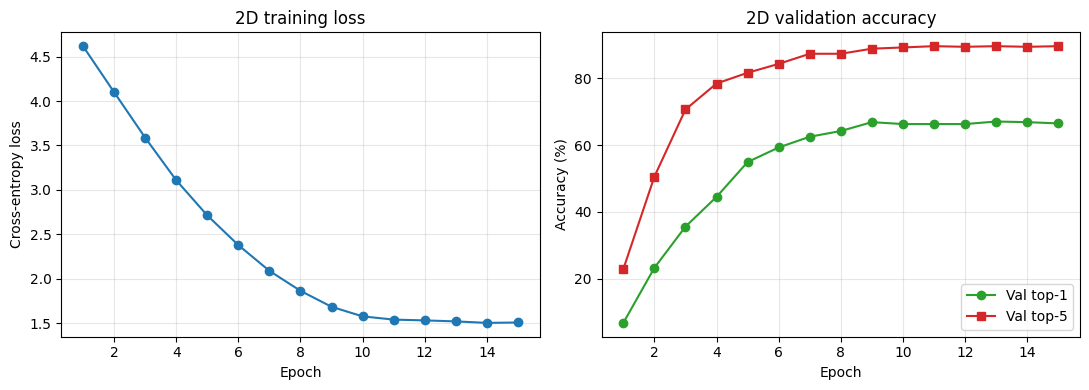

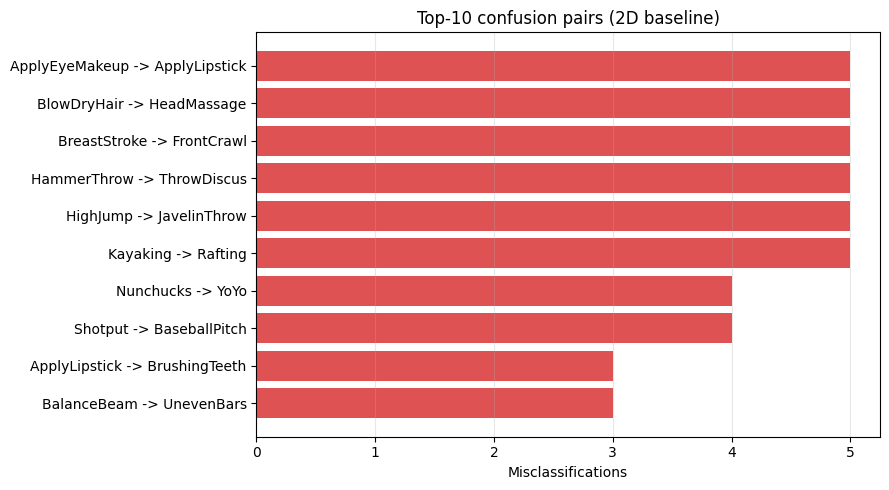

[2D] Phase complete. CSV and figures saved.


In [ ]:
# 2D test evaluation + per-class CSV + figures
ckpt = torch.load(best_2d_path, map_location=DEVICE)
model_2d.load_state_dict(ckpt['model_state'])
print(f"[2D] Loaded best checkpoint epoch {ckpt['epoch']}")
test1_2d, test5_2d, L2d, Y2d, P2d = eval_2d(model_2d, test_loader_2d)
print(f'[2D] Test top-1 {test1_2d*100:.2f}% | top-5 {test5_2d*100:.2f}%')

# Per-class CSV
preds_2d = L2d.argmax(-1).numpy(); labs_2d = Y2d.numpy()
corr = defaultdict(int); tot = defaultdict(int)
for t,p in zip(labs_2d, preds_2d):
    tot[int(t)] += 1
    if t == p: corr[int(t)] += 1
rows = [{'class_id': c, 'class': id_to_name[c], 'n_test': tot[c], 'n_correct': corr[c],
         'top1_acc': corr[c]/tot[c] if tot[c] else float('nan')} for c in range(NUM_CLASSES)]
df_2d = pd.DataFrame(rows).sort_values('top1_acc', ascending=False)
df_2d.to_csv(f'{OUTPUT_DIR}/per_class_accuracy_2d.csv', index=False)

# Figure: 2D training curves
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(history_2d['epoch'], history_2d['train_loss'], '-o')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss'); axes[0].set_title('2D training loss'); axes[0].grid(alpha=0.3)
axes[1].plot(history_2d['epoch'], [v*100 for v in history_2d['val_top1']], '-o', label='Val top-1', color='C2')
axes[1].plot(history_2d['epoch'], [v*100 for v in history_2d['val_top5']], '-s', label='Val top-5', color='C3')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('2D validation accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/2d_baseline_curves.png', dpi=150, bbox_inches='tight'); plt.show()

# Figure: 2D confusion pairs
wrong = preds_2d != labs_2d
pc = Counter()
for t,p in zip(labs_2d[wrong], preds_2d[wrong]): pc[(int(t),int(p))] += 1
top_pairs_2d = pc.most_common(10)
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(range(10)[::-1], [c for _,c in top_pairs_2d], color='C3', alpha=0.8)
ax.set_yticks(range(10)[::-1])
ax.set_yticklabels([f'{id_to_name[t]} -> {id_to_name[p]}' for (t,p),_ in top_pairs_2d])
ax.set_xlabel('Misclassifications'); ax.set_title('Top-10 confusion pairs (2D baseline)'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/2d_baseline_confusion.png', dpi=150, bbox_inches='tight'); plt.show()

print('[2D] Phase complete. CSV and figures saved.')

In [ ]:
# test-frame ablation for the report's caveats section
@torch.no_grad()
def eval_with_n_frames_2d(model, items, n_use):
    model.eval(); correct=total=0
    for rel,label,_ in items:
        d = Path(FRAMES_DIR)/video_id(rel)
        if not d.exists(): continue
        idxs = np.linspace(0, FRAMES_PER_VIDEO-1, n_use).astype(int)
        imgs = torch.stack([eval_tf_2d(Image.open(d/f'frame_{i:02d}.jpg').convert('RGB')) for i in idxs]).to(DEVICE)
        if model(imgs).softmax(-1).mean(0).argmax().item() == label: correct += 1
        total += 1
    return correct/max(total,1)

ablation_2d = {}
for n in [1, 4, 8, 16]:
    if n > FRAMES_PER_VIDEO: continue
    a = eval_with_n_frames_2d(model_2d, test_items, n)
    ablation_2d[n] = a
    print(f'  n_frames={n:2d}: top-1 = {a*100:.2f}%')
with open(f'{OUTPUT_DIR}/test_frame_ablation.json','w') as f: json.dump(ablation_2d, f, indent=2)

# Free GPU memory before Phase 2
del model_2d, opt_2d, sch_2d, train_loader_2d, val_loader_2d, test_loader_2d
del train_ds_2d, val_ds_2d, test_ds_2d
torch.cuda.empty_cache()
print('[2D] Phase done. GPU memory cleared. Moving to Phase 2.')

  n_frames= 1: top-1 = 55.25%
  n_frames= 4: top-1 = 63.17%
  n_frames= 8: top-1 = 62.77%
  n_frames=16: top-1 = 62.38%
[2D] Phase done. GPU memory cleared. Moving to Phase 2.



# Phase 2: R(2+1)D-18 (3D CNN)


In [ ]:
KIN_MEAN = R2Plus1D_18_Weights.KINETICS400_V1.transforms().mean
KIN_STD  = R2Plus1D_18_Weights.KINETICS400_V1.transforms().std
print(f'Kinetics stats: mean={KIN_MEAN} std={KIN_STD}')

class ClipDataset(Dataset):
    """Reads R2D_CLIP_LEN frames per video, returns clip shaped (3, T, H, W).
    Clip-consistent augmentation: same crop and flip applied to every frame."""
    def __init__(self, items, frames_root, clip_len, img_size, training):
        self.items = [it for it in items if (Path(frames_root)/video_id(it[0])).exists()]
        self.frames_root = Path(frames_root)
        self.clip_len = clip_len; self.img_size = img_size; self.training = training
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        rel, label, _ = self.items[i]
        d = self.frames_root/video_id(rel)
        imgs = [Image.open(d/f'frame_{j:02d}.jpg').convert('RGB') for j in range(self.clip_len)]
        W, H = imgs[0].size
        if self.training:
            s = random.uniform(0.6, 1.0); ch=int(H*s); cw=int(W*s)
            top = random.randint(0, H-ch); left = random.randint(0, W-cw)
            flip = random.random() < 0.5
        else:
            ch = cw = min(H, W); top = (H-ch)//2; left = (W-cw)//2; flip = False
        frames = []
        for img in imgs:
            img = img.crop((left,top,left+cw,top+ch)).resize((self.img_size,self.img_size), Image.BILINEAR)
            if flip: img = img.transpose(Image.FLIP_LEFT_RIGHT)
            frames.append(np.asarray(img, dtype=np.float32)/255.0)
        clip = torch.from_numpy(np.stack(frames,0).transpose(3,0,1,2))  # (3,T,H,W)
        for c in range(3): clip[c] = (clip[c]-KIN_MEAN[c])/KIN_STD[c]
        return clip, label, rel

def train_collate(b):
    return torch.stack([x[0] for x in b]), torch.tensor([x[1] for x in b])
def eval_collate(b):
    return torch.stack([x[0] for x in b]), torch.tensor([x[1] for x in b]), [x[2] for x in b]

train_ds_r2d = ClipDataset(train_items, FRAMES_DIR, R2D_CLIP_LEN, R2D_IMG_SIZE, training=True)
val_ds_r2d   = ClipDataset(val_items,   FRAMES_DIR, R2D_CLIP_LEN, R2D_IMG_SIZE, training=False)
test_ds_r2d  = ClipDataset(test_items,  FRAMES_DIR, R2D_CLIP_LEN, R2D_IMG_SIZE, training=False)

train_loader_r2d = DataLoader(train_ds_r2d, batch_size=R2D_BATCH, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True, collate_fn=train_collate)
val_loader_r2d   = DataLoader(val_ds_r2d, batch_size=R2D_BATCH, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, collate_fn=eval_collate)
test_loader_r2d  = DataLoader(test_ds_r2d, batch_size=R2D_BATCH, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True, collate_fn=eval_collate)

print(f'R2D Train clips: {len(train_ds_r2d)} | Val: {len(val_ds_r2d)} | Test: {len(test_ds_r2d)}')
x,y = next(iter(train_loader_r2d))
print(f'Sample batch: {x.shape} {x.dtype}')

Kinetics stats: mean=[0.43216, 0.394666, 0.37645] std=[0.22803, 0.22145, 0.216989]
R2D Train clips: 3030 | Val: 528 | Test: 1010
Sample batch: torch.Size([4, 3, 16, 112, 112]) torch.float32


/Users/sikanderraheem/Documents/VideoActionRecognition/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
model_r2d = r2plus1d_18(weights=R2Plus1D_18_Weights.KINETICS400_V1)
model_r2d.fc = nn.Linear(model_r2d.fc.in_features, NUM_CLASSES)
model_r2d = model_r2d.to(DEVICE)

opt_r2d = optim.SGD(model_r2d.parameters(), lr=R2D_LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
sch_r2d = optim.lr_scheduler.MultiStepLR(opt_r2d, milestones=[int(R2D_EPOCHS*0.6), int(R2D_EPOCHS*0.8)], gamma=0.1)
print(f'R(2+1)D-18 ready. {sum(p.numel() for p in model_r2d.parameters())/1e6:.2f}M params')

Downloading: "https://download.pytorch.org/models/r2plus1d_18-91a641e6.pth" to /Users/sikanderraheem/.cache/torch/hub/checkpoints/r2plus1d_18-91a641e6.pth


100%|██████████| 120M/120M [00:23<00:00, 5.33MB/s] 


R(2+1)D-18 ready. 31.35M params


In [ ]:
# Resume support: per-epoch checkpoint to Drive
last_r2d_path = Path(CKPT_DIR)/'last_r2d.pt'
best_r2d_path = Path(CKPT_DIR)/'best_r2d.pt'
history_r2d = {'epoch': [], 'train_loss': [], 'val_top1': [], 'val_top5': []}
best_r2d = 0.0
start_epoch = 1

if last_r2d_path.exists():
    s = torch.load(last_r2d_path, map_location=DEVICE)
    model_r2d.load_state_dict(s['model_state'])
    opt_r2d.load_state_dict(s['opt_state'])
    sch_r2d.load_state_dict(s['sch_state'])
    start_epoch = s['epoch'] + 1
    history_r2d = s.get('history', history_r2d)
    best_r2d = s.get('best_r2d', 0.0)
    print(f'Resumed R(2+1)D from epoch {start_epoch}. Best so far: {best_r2d*100:.2f}%')
else:
    print('Starting R(2+1)D from scratch.')

Starting R(2+1)D from scratch.


In [ ]:
@torch.no_grad()
def eval_r2d(model, loader):
    model.eval()
    Ls, Ys, Ps = [], [], []
    for clips, labels, paths in loader:
        clips = clips.to(DEVICE, non_blocking=True)
        Ls.append(model(clips).softmax(-1).cpu()); Ys.append(labels); Ps.extend(paths)
    L = torch.cat(Ls); Y = torch.cat(Ys)
    top1 = (L.argmax(-1)==Y).float().mean().item()
    top5 = sum(Y[i].item() in L[i].topk(5).indices.tolist() for i in range(len(Y))) / len(Y)
    return top1, top5, L, Y, Ps

for epoch in range(start_epoch, R2D_EPOCHS+1):
    model_r2d.train()
    running, seen = 0.0, 0
    pbar = tqdm(train_loader_r2d, desc=f'[R2D] Ep {epoch}/{R2D_EPOCHS}')
    for x, y in pbar:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        opt_r2d.zero_grad(); loss = criterion(model_r2d(x), y); loss.backward(); opt_r2d.step()
        running += loss.item()*x.size(0); seen += x.size(0)
        pbar.set_postfix(loss=f'{running/seen:.3f}')
    sch_r2d.step()
    tl = running/max(seen,1)
    v1, v5, *_ = eval_r2d(model_r2d, val_loader_r2d)
    history_r2d['epoch'].append(epoch); history_r2d['train_loss'].append(tl)
    history_r2d['val_top1'].append(v1); history_r2d['val_top5'].append(v5)
    print(f'  train_loss={tl:.3f} val_top1={v1*100:.2f}% val_top5={v5*100:.2f}%')

    torch.save({'model_state': model_r2d.state_dict(), 'opt_state': opt_r2d.state_dict(),
                'sch_state': sch_r2d.state_dict(), 'epoch': epoch,
                'history': history_r2d, 'best_r2d': best_r2d}, last_r2d_path)
    if v1 > best_r2d:
        best_r2d = v1
        torch.save({'model_state': model_r2d.state_dict(), 'epoch': epoch, 'val_top1': v1}, best_r2d_path)
        print(f'  ** new best (saved to Drive)')

with open(f'{OUTPUT_DIR}/history_r2d.json','w') as f: json.dump(history_r2d, f, indent=2)
print(f'\n[R2D] Best val top-1: {best_r2d*100:.2f}%')

[R2D] Ep 1/15:   0%|          | 0/757 [00:00<?, ?it/s]

  train_loss=3.387 val_top1=72.92% val_top5=98.11%
  ** new best (saved to Drive)


[R2D] Ep 2/15:   0%|          | 0/757 [00:00<?, ?it/s]

  train_loss=1.343 val_top1=84.47% val_top5=99.24%
  ** new best (saved to Drive)


[R2D] Ep 3/15:   0%|          | 0/757 [00:00<?, ?it/s]

...

  train_loss=0.080 val_top1=89.96% val_top5=99.24%


[R2D] Ep 14/15:   0%|          | 0/757 [00:00<?, ?it/s]

  train_loss=0.090 val_top1=90.72% val_top5=99.24%


[R2D] Ep 15/15:   0%|          | 0/757 [00:00<?, ?it/s]

  train_loss=0.100 val_top1=91.48% val_top5=99.05%
  ** new best (saved to Drive)

[R2D] Best val top-1: 91.48%


[R2D] Loaded best checkpoint epoch 15
[R2D] Test top-1 90.30% | top-5 98.81%


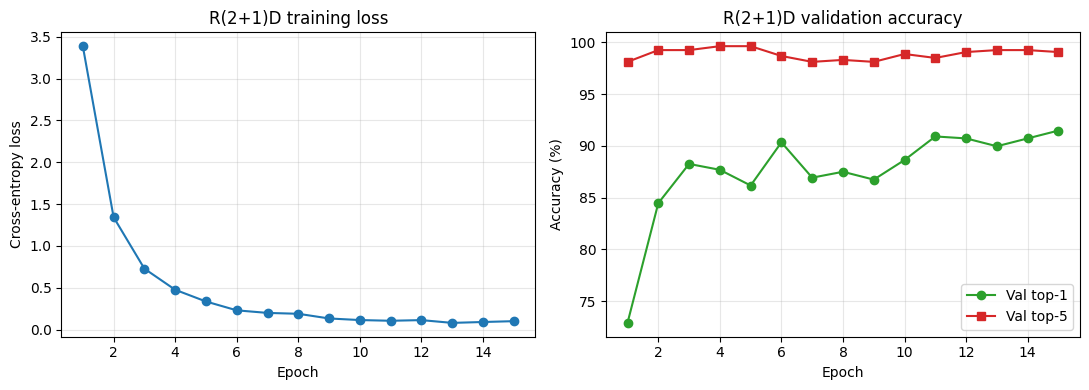

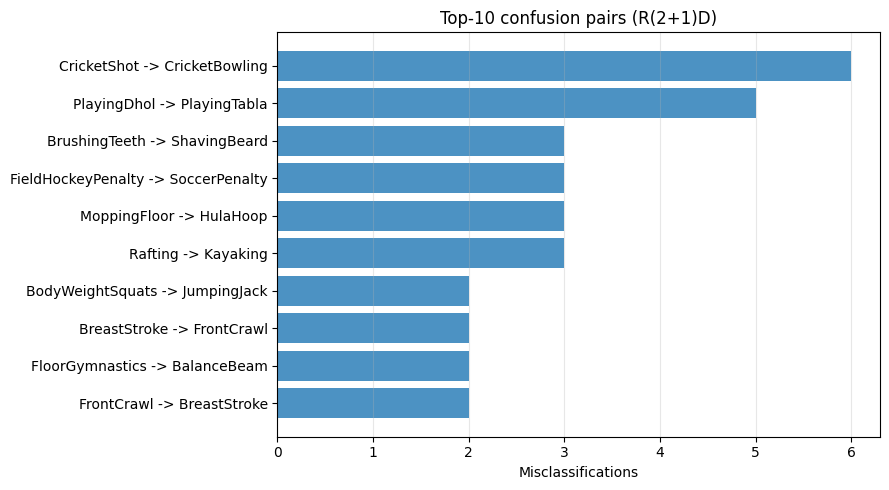

[R2D] Phase complete.


In [ ]:
# R(2+1)D test evaluation + per-class CSV + figures
ckpt = torch.load(best_r2d_path, map_location=DEVICE)
model_r2d.load_state_dict(ckpt['model_state'])
print(f"[R2D] Loaded best checkpoint epoch {ckpt['epoch']}")
test1_r2d, test5_r2d, Lr2, Yr2, Pr2 = eval_r2d(model_r2d, test_loader_r2d)
print(f'[R2D] Test top-1 {test1_r2d*100:.2f}% | top-5 {test5_r2d*100:.2f}%')

preds_r2d = Lr2.argmax(-1).numpy(); labs_r2d = Yr2.numpy()
corr = defaultdict(int); tot = defaultdict(int)
for t,p in zip(labs_r2d, preds_r2d):
    tot[int(t)] += 1
    if t == p: corr[int(t)] += 1
rows = [{'class_id': c, 'class': id_to_name[c], 'n_test': tot[c], 'n_correct': corr[c],
         'top1_acc': corr[c]/tot[c] if tot[c] else float('nan')} for c in range(NUM_CLASSES)]
df_r2d = pd.DataFrame(rows).sort_values('top1_acc', ascending=False)
df_r2d.to_csv(f'{OUTPUT_DIR}/per_class_accuracy_r2plus1d.csv', index=False)

# Figure: R(2+1)D training curves
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(history_r2d['epoch'], history_r2d['train_loss'], '-o')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss'); axes[0].set_title('R(2+1)D training loss'); axes[0].grid(alpha=0.3)
axes[1].plot(history_r2d['epoch'], [v*100 for v in history_r2d['val_top1']], '-o', label='Val top-1', color='C2')
axes[1].plot(history_r2d['epoch'], [v*100 for v in history_r2d['val_top5']], '-s', label='Val top-5', color='C3')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('R(2+1)D validation accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/r2plus1d_curves.png', dpi=150, bbox_inches='tight'); plt.show()

# Figure: R(2+1)D confusion pairs
wrong = preds_r2d != labs_r2d
pc = Counter()
for t,p in zip(labs_r2d[wrong], preds_r2d[wrong]): pc[(int(t),int(p))] += 1
top_pairs_r2d = pc.most_common(10)
fig, ax = plt.subplots(figsize=(9,5))
ax.barh(range(10)[::-1], [c for _,c in top_pairs_r2d], color='C0', alpha=0.8)
ax.set_yticks(range(10)[::-1])
ax.set_yticklabels([f'{id_to_name[t]} -> {id_to_name[p]}' for (t,p),_ in top_pairs_r2d])
ax.set_xlabel('Misclassifications'); ax.set_title('Top-10 confusion pairs (R(2+1)D)'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/r2plus1d_confusion.png', dpi=150, bbox_inches='tight'); plt.show()

print('[R2D] Phase complete.')

# Phase 3: Ablation -- 2D Baseline vs. R(2+1)D

In [ ]:
# Three-model comparison table
comparison = {
    '2d_baseline': {'top1': test1_2d, 'top5': test5_2d, 'n_test': len(Y2d)},
    'r2plus1d':    {'top1': test1_r2d, 'top5': test5_r2d, 'n_test': len(Yr2)},
    'delta':       {'top1': test1_r2d - test1_2d, 'top5': test5_r2d - test5_2d},
}
with open(f'{OUTPUT_DIR}/model_comparison.json', 'w') as f:
    json.dump(comparison, f, indent=2)

print('=' * 60)
print(f'{"Model":30s} {"Top-1 (%)":>12s} {"Top-5 (%)":>12s}')
print('=' * 60)
print(f'{"2D Baseline (ResNet-18)":30s} {test1_2d*100:>12.2f} {test5_2d*100:>12.2f}')
print(f'{"R(2+1)D-18":30s} {test1_r2d*100:>12.2f} {test5_r2d*100:>12.2f}')
print('=' * 60)
print(f'{"Delta (R2D - 2D)":30s} {(test1_r2d-test1_2d)*100:>+12.2f} {(test5_r2d-test5_2d)*100:>+12.2f}')
print()
if test1_r2d > test1_2d:
    print(f'R(2+1)D gains {(test1_r2d-test1_2d)*100:+.2f} percentage points top-1 over the 2D baseline.')
else:
    print(f'R(2+1)D unexpectedly performed worse. Investigate before reporting.')

Model                             Top-1 (%)    Top-5 (%)
2D Baseline (ResNet-18)               62.38        87.03
R(2+1)D-18                            90.30        98.81
Delta (R2D - 2D)                     +27.92       +11.78

R(2+1)D gains +27.92 percentage points top-1 over the 2D baseline.


In [ ]:
# Per-class comparison: where does temporal modeling help?
df_2d_j = df_2d[['class','top1_acc']].rename(columns={'top1_acc':'top1_2d'})
df_r2d_j = df_r2d[['class','top1_acc']].rename(columns={'top1_acc':'top1_r2d'})
df_cmp = df_2d_j.merge(df_r2d_j, on='class')
df_cmp['delta'] = df_cmp['top1_r2d'] - df_cmp['top1_2d']
df_cmp = df_cmp.sort_values('delta', ascending=False)
df_cmp.to_csv(f'{OUTPUT_DIR}/per_class_comparison.csv', index=False)

print('=== 10 classes where R(2+1)D helps MOST ===')
print(df_cmp.head(10).to_string(index=False))
print('\n=== 10 classes where R(2+1)D helps LEAST (or hurts) ===')
print(df_cmp.tail(10).to_string(index=False))
print(f'\nMean delta : {df_cmp["delta"].mean()*100:.2f} pts')
print(f'Median delta: {df_cmp["delta"].median()*100:.2f} pts')
print(f'Improved: {(df_cmp["delta"]>0).sum()}/{len(df_cmp)}  |  Hurt: {(df_cmp["delta"]<0).sum()}/{len(df_cmp)}')

=== 10 classes where R(2+1)D helps MOST ===
         class  top1_2d  top1_r2d  delta
   JumpingJack      0.1       1.0    0.9
    Basketball      0.1       0.8    0.7
      HighJump      0.1       0.8    0.7
      JumpRope      0.3       1.0    0.7
SoccerJuggling      0.3       1.0    0.7
   TennisSwing      0.2       0.9    0.7
      Kayaking      0.3       1.0    0.7
  RopeClimbing      0.2       0.9    0.7
      HulaHoop      0.3       1.0    0.7
   CliffDiving      0.3       1.0    0.7

=== 10 classes where R(2+1)D helps LEAST (or hurts) ===
             class  top1_2d  top1_r2d  delta
    MilitaryParade      0.9       0.9    0.0
      BandMarching      0.9       0.9    0.0
FieldHockeyPenalty      0.7       0.7    0.0
         HorseRace      1.0       1.0    0.0
      PlayingSitar      1.0       0.9   -0.1
       CricketShot      0.5       0.4   -0.1
     PlayingViolin      1.0       0.9   -0.1
           Rafting      0.8       0.7   -0.1
            Mixing      0.9       0.7   -0.

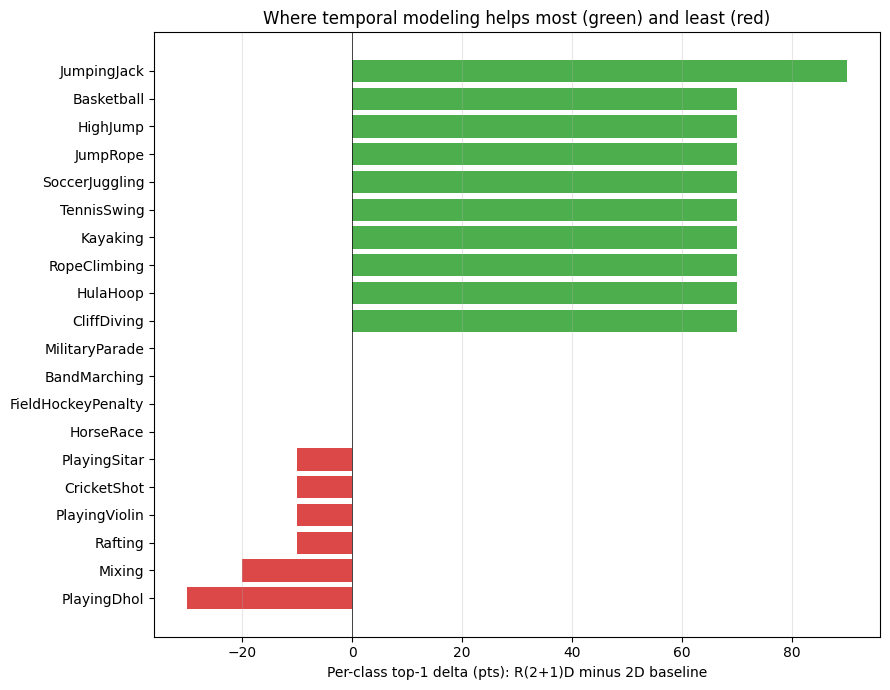

Saved: /Users/sikanderraheem/Documents/VideoActionRecognition/outputs/figures/per_class_delta.png


In [ ]:
# Figure: per-class delta bar chart
top_imp = df_cmp.head(10); top_hurt = df_cmp.tail(10)
plot_df = pd.concat([top_imp, top_hurt])
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['C2' if d > 0 else 'C3' for d in plot_df['delta']]
ax.barh(range(len(plot_df))[::-1], plot_df['delta']*100, color=colors, alpha=0.85)
ax.set_yticks(range(len(plot_df))[::-1])
ax.set_yticklabels(plot_df['class'])
ax.axvline(0, color='black', lw=0.5)
ax.set_xlabel('Per-class top-1 delta (pts): R(2+1)D minus 2D baseline')
ax.set_title('Where temporal modeling helps most (green) and least (red)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/per_class_delta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', f'{FIGURES_DIR}/per_class_delta.png')

# Phase 3: Optical Flow Precomputation (RAFT)

In [ ]:
# Free memory from R(2+1)D model before flow precomputation
try:
    del model_r2d, opt_r2d, sch_r2d, train_loader_r2d, val_loader_r2d, test_loader_r2d
    del train_ds_r2d, val_ds_r2d, test_ds_r2d
except NameError:
    pass
torch.cuda.empty_cache()
print('Cleared R(2+1)D resources.')

# RAFT setup
from torchvision.models.optical_flow import raft_small, Raft_Small_Weights

FLOW_DIR = f'{DATA_ROOT}/flow'
Path(FLOW_DIR).mkdir(parents=True, exist_ok=True)

FLOW_IMG_SIZE = 224       # RAFT expects multiples of 8; 224 is also our temporal-stream input size
FLOW_CLIP_VALUE = 20      # clip flow magnitudes to ±20 pixels (standard practice)

raft_weights = Raft_Small_Weights.DEFAULT
raft_model = raft_small(weights=raft_weights, progress=False).to(DEVICE).eval()
raft_transforms = raft_weights.transforms()
for p in raft_model.parameters():
    p.requires_grad_(False)
print('RAFT-small loaded.')

Cleared R(2+1)D resources.
Downloading: "https://download.pytorch.org/models/raft_small_C_T_V2-01064c6d.pth" to /Users/sikanderraheem/.cache/torch/hub/checkpoints/raft_small_C_T_V2-01064c6d.pth
RAFT-small loaded.


In [ ]:
# Helper: load 16 frames for a video and prepare for RAFT
def load_frames_for_flow(rel, size):
    d = Path(FRAMES_DIR) / video_id(rel)
    imgs = []
    for j in range(FRAMES_PER_VIDEO):
        p = d / f'frame_{j:02d}.jpg'
        img = Image.open(p).convert('RGB').resize((size, size), Image.BILINEAR)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        imgs.append(arr)
    # shape (T, H, W, 3) -> (T, 3, H, W)
    return torch.from_numpy(np.stack(imgs).transpose(0, 3, 1, 2))

@torch.no_grad()
def compute_flow_for_video(rel, size=FLOW_IMG_SIZE):
    out_path = Path(FLOW_DIR) / f'{video_id(rel)}.npy'
    if out_path.exists():
        return True
    frames = load_frames_for_flow(rel, size).to(DEVICE)  # (T, 3, H, W) in [0,1]
    # Build consecutive pairs: (T-1, 3, H, W) each
    img1 = frames[:-1]   # frames 0..T-2
    img2 = frames[1:]    # frames 1..T-1
    # RAFT's own transform expects pairs and returns normalized images
    img1, img2 = raft_transforms(img1, img2)
    # RAFT iterates internally; final flow is the last item in the returned list
    flows = raft_model(img1, img2)
    flow = flows[-1].cpu().numpy()  # (T-1, 2, H, W) in pixels (signed)
    # Clip and quantize to int8 to save disk (range [-20, 20] -> [-127, 127])
    flow = np.clip(flow, -FLOW_CLIP_VALUE, FLOW_CLIP_VALUE)
    flow = (flow / FLOW_CLIP_VALUE * 127.0).astype(np.int8)  # int8 saves 4× disk vs float32
    np.save(out_path, flow)
    return True

# Run flow precomputation (skip-if-exists)
all_items = train_items + val_items + test_items
to_compute = [it for it in all_items if not (Path(FLOW_DIR) / f'{video_id(it[0])}.npy').exists()]
print(f'Need flow for {len(to_compute)} videos (out of {len(all_items)}).')

t0 = time.time()
ok, fail = 0, 0
for rel, _, _ in tqdm(to_compute):
    try:
        compute_flow_for_video(rel)
        ok += 1
    except Exception as e:
        print(f'  failed for {rel}: {e}')
        fail += 1

# Free RAFT memory before training
del raft_model
torch.cuda.empty_cache()
print(f'\nFlow precomputation done in {(time.time()-t0)/60:.1f} min. OK={ok} Failed={fail}')
print(f'Flow files on disk: {len(list(Path(FLOW_DIR).glob("*.npy")))}')

Need flow for 4568 videos (out of 4568).


  0%|          | 0/4568 [00:00<?, ?it/s]


Flow precomputation done in 17.4 min. OK=4568 Failed=0
Flow files on disk: 4568


# Phase 4: Temporal Stream Training (ResNet-18 on optical flow)
This is the *temporal stream* of the classical two-stream network. The *spatial stream* is already trained as 2D baseline (model_2d from Phase 1).

In [ ]:
TS_FLOW_STACK = 10       # number of consecutive flow frames to stack -> 20 input channels
TS_IMG_SIZE = 224
TS_BATCH = 32
TS_EPOCHS = 30           # longer than 2D baseline -- flow features are further from ImageNet
TS_LR = 1e-3

class FlowDataset(Dataset):
    """Loads (TS_FLOW_STACK, 2, H, W) flow stack per __getitem__, returns (20, H, W) tensor."""
    def __init__(self, items, flow_dir, stack_len, img_size, training):
        self.items = [it for it in items if (Path(flow_dir) / f'{video_id(it[0])}.npy').exists()]
        self.flow_dir = Path(flow_dir)
        self.stack_len = stack_len
        self.img_size = img_size
        self.training = training
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        rel, label, _ = self.items[i]
        flow_full = np.load(self.flow_dir / f'{video_id(rel)}.npy')  # int8, (T-1, 2, H, W)
        T_full = flow_full.shape[0]
        # Sample a window of stack_len consecutive flow frames
        if self.training:
            start = random.randint(0, max(0, T_full - self.stack_len))
        else:
            start = max(0, (T_full - self.stack_len) // 2)
        stack = flow_full[start:start + self.stack_len]  # (stack_len, 2, H, W)
        # Dequantize int8 -> float32 in original [-CLIP, CLIP] range
        stack = stack.astype(np.float32) / 127.0 * FLOW_CLIP_VALUE  # back to pixel units
        # Then normalize to roughly [-1, 1] (divide by clip value)
        stack = stack / FLOW_CLIP_VALUE
        H, W = stack.shape[2], stack.shape[3]
        # Clip-consistent crop and flip
        if self.training:
            s = random.uniform(0.6, 1.0); ch=int(H*s); cw=int(W*s)
            top = random.randint(0, H-ch); left = random.randint(0, W-cw)
            flip = random.random() < 0.5
        else:
            ch = cw = min(H, W); top = (H-ch)//2; left = (W-cw)//2; flip = False
        stack = stack[:, :, top:top+ch, left:left+cw]
        # Resize each (2, ch, cw) frame to (2, img_size, img_size) -- use PIL via per-channel handling
        resized = np.empty((self.stack_len, 2, self.img_size, self.img_size), dtype=np.float32)
        for t in range(self.stack_len):
            for c in range(2):
                arr = stack[t, c]
                # Use bilinear via PIL after rescaling for numerical stability
                img = Image.fromarray((arr * 127.5 + 127.5).clip(0, 255).astype(np.uint8))
                img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
                resized[t, c] = (np.asarray(img, dtype=np.float32) - 127.5) / 127.5
        if flip:
            resized = resized[:, :, :, ::-1].copy()
            resized[:, 0, :, :] *= -1  # horizontal flow component flips sign on horizontal flip
        # Reshape to (20, H, W) by interleaving as (stack_len, 2, H, W) -> (stack_len*2, H, W)
        out = resized.reshape(self.stack_len * 2, self.img_size, self.img_size)
        return torch.from_numpy(out), label, rel

train_ds_ts = FlowDataset(train_items, FLOW_DIR, TS_FLOW_STACK, TS_IMG_SIZE, training=True)
val_ds_ts   = FlowDataset(val_items,   FLOW_DIR, TS_FLOW_STACK, TS_IMG_SIZE, training=False)
test_ds_ts  = FlowDataset(test_items,  FLOW_DIR, TS_FLOW_STACK, TS_IMG_SIZE, training=False)

def ts_train_collate(b):
    return torch.stack([x[0] for x in b]), torch.tensor([x[1] for x in b])
def ts_eval_collate(b):
    return torch.stack([x[0] for x in b]), torch.tensor([x[1] for x in b]), [x[2] for x in b]

train_loader_ts = DataLoader(train_ds_ts, batch_size=TS_BATCH, shuffle=True,
                             num_workers=NUM_WORKERS, pin_memory=True, drop_last=True, collate_fn=ts_train_collate)
val_loader_ts   = DataLoader(val_ds_ts, batch_size=TS_BATCH, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True, collate_fn=ts_eval_collate)
test_loader_ts  = DataLoader(test_ds_ts, batch_size=TS_BATCH, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True, collate_fn=ts_eval_collate)

print(f'Temporal stream | Train: {len(train_ds_ts)} | Val: {len(val_ds_ts)} | Test: {len(test_ds_ts)}')
# Sanity-check one batch
xs, ys = next(iter(train_loader_ts))
print(f'Batch: shape={tuple(xs.shape)} dtype={xs.dtype} range=[{xs.min():.2f}, {xs.max():.2f}] mean={xs.mean():.3f}')

Temporal stream | Train: 3030 | Val: 528 | Test: 1010


/Users/sikanderraheem/Documents/VideoActionRecognition/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Batch: shape=(32, 20, 224, 224) dtype=torch.float32 range=[-1.00, 1.00] mean=-0.019


In [ ]:
def build_temporal_stream():
    """ResNet-18 with first conv expanded from 3->20 channels via cross-modality init."""
    m = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    # Original first conv: (out_ch=64, in_ch=3, k=7, k=7)
    orig_conv1 = m.conv1
    new_conv1 = nn.Conv2d(TS_FLOW_STACK * 2, orig_conv1.out_channels,
                          kernel_size=orig_conv1.kernel_size,
                          stride=orig_conv1.stride,
                          padding=orig_conv1.padding,
                          bias=False)
    # Cross-modality init: average RGB weights across in_ch dimension, then replicate
    with torch.no_grad():
        avg_w = orig_conv1.weight.data.mean(dim=1, keepdim=True)  # (64, 1, 7, 7)
        new_conv1.weight.data = avg_w.repeat(1, TS_FLOW_STACK * 2, 1, 1)
        # Scale down so the activations have similar magnitude as the original 3-channel conv
        new_conv1.weight.data /= (TS_FLOW_STACK * 2) / 3.0
    m.conv1 = new_conv1
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

model_ts = build_temporal_stream().to(DEVICE)
opt_ts = optim.SGD(model_ts.parameters(), lr=TS_LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
sch_ts = optim.lr_scheduler.MultiStepLR(opt_ts, milestones=[int(TS_EPOCHS*0.6), int(TS_EPOCHS*0.8)], gamma=0.1)
print(f'Temporal stream ready. {sum(p.numel() for p in model_ts.parameters())/1e6:.2f}M params')
print(f'First conv: {model_ts.conv1}')

Temporal stream ready. 11.28M params
First conv: Conv2d(20, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)


In [ ]:
# Resume support for the temporal stream
last_ts_path = Path(CKPT_DIR)/'last_ts.pt'
best_ts_path = Path(CKPT_DIR)/'best_ts.pt'
history_ts = {'epoch': [], 'train_loss': [], 'val_top1': [], 'val_top5': []}
best_ts = 0.0
start_ts_epoch = 1

if last_ts_path.exists():
    s = torch.load(last_ts_path, map_location=DEVICE)
    model_ts.load_state_dict(s['model_state'])
    opt_ts.load_state_dict(s['opt_state'])
    sch_ts.load_state_dict(s['sch_state'])
    start_ts_epoch = s['epoch'] + 1
    history_ts = s.get('history', history_ts)
    best_ts = s.get('best_ts', 0.0)
    print(f'Resumed temporal stream from epoch {start_ts_epoch}. Best so far: {best_ts*100:.2f}%')
else:
    print('Starting temporal stream from scratch.')

@torch.no_grad()
def eval_ts(model, loader):
    model.eval()
    Ls, Ys, Ps = [], [], []
    for x, y, paths in loader:
        x = x.to(DEVICE, non_blocking=True)
        Ls.append(model(x).softmax(-1).cpu()); Ys.append(y); Ps.extend(paths)
    L = torch.cat(Ls); Y = torch.cat(Ys)
    top1 = (L.argmax(-1)==Y).float().mean().item()
    top5 = sum(Y[i].item() in L[i].topk(5).indices.tolist() for i in range(len(Y))) / len(Y)
    return top1, top5, L, Y, Ps

for epoch in range(start_ts_epoch, TS_EPOCHS+1):
    model_ts.train()
    running, seen = 0.0, 0
    pbar = tqdm(train_loader_ts, desc=f'[TS] Ep {epoch}/{TS_EPOCHS}')
    for x, y in pbar:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        opt_ts.zero_grad(); loss = criterion(model_ts(x), y); loss.backward(); opt_ts.step()
        running += loss.item()*x.size(0); seen += x.size(0)
        pbar.set_postfix(loss=f'{running/seen:.3f}')
    sch_ts.step()
    tl = running/max(seen,1)
    v1, v5, *_ = eval_ts(model_ts, val_loader_ts)
    history_ts['epoch'].append(epoch); history_ts['train_loss'].append(tl)
    history_ts['val_top1'].append(v1); history_ts['val_top5'].append(v5)
    print(f'  train_loss={tl:.3f} val_top1={v1*100:.2f}% val_top5={v5*100:.2f}%')

    torch.save({'model_state': model_ts.state_dict(), 'opt_state': opt_ts.state_dict(),
                'sch_state': sch_ts.state_dict(), 'epoch': epoch,
                'history': history_ts, 'best_ts': best_ts}, last_ts_path)
    if v1 > best_ts:
        best_ts = v1
        torch.save({'model_state': model_ts.state_dict(), 'epoch': epoch, 'val_top1': v1}, best_ts_path)
        print(f'  ** new best (saved to Drive)')

with open(f'{OUTPUT_DIR}/history_ts.json','w') as f: json.dump(history_ts, f, indent=2)
print(f'\n[TS] Best val top-1: {best_ts*100:.2f}%')

Starting temporal stream from scratch.


[TS] Ep 1/30:   0%|          | 0/94 [00:00<?, ?it/s]

  train_loss=4.636 val_top1=2.46% val_top5=13.07%
  ** new best (saved to Drive)


[TS] Ep 2/30:   0%|          | 0/94 [00:00<?, ?it/s]

  train_loss=4.334 val_top1=6.06% val_top5=18.18%
  ** new best (saved to Drive)


...

  train_loss=2.138 val_top1=27.84% val_top5=62.50%


[TS] Ep 29/30:   0%|          | 0/94 [00:00<?, ?it/s]

  train_loss=2.148 val_top1=29.55% val_top5=62.31%


[TS] Ep 30/30:   0%|          | 0/94 [00:00<?, ?it/s]

  train_loss=2.133 val_top1=29.17% val_top5=61.36%

[TS] Best val top-1: 29.55%


[TS] Loaded best checkpoint epoch 17
[TS] Test top-1 28.32% | top-5 59.41%


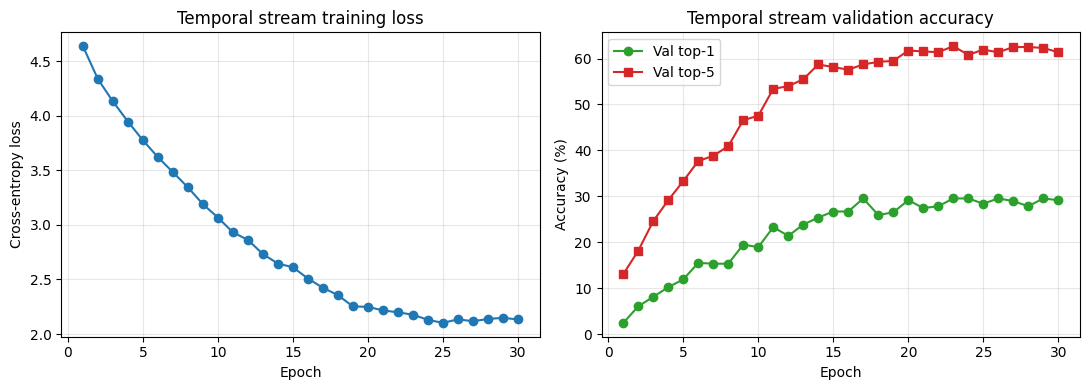

[TS] Phase complete.


In [ ]:
# Temporal stream test evaluation + per-class CSV
ckpt = torch.load(best_ts_path, map_location=DEVICE)
model_ts.load_state_dict(ckpt['model_state'])
print(f"[TS] Loaded best checkpoint epoch {ckpt['epoch']}")
test1_ts, test5_ts, Lts, Yts, Pts = eval_ts(model_ts, test_loader_ts)
print(f'[TS] Test top-1 {test1_ts*100:.2f}% | top-5 {test5_ts*100:.2f}%')

preds_ts = Lts.argmax(-1).numpy(); labs_ts = Yts.numpy()
corr = defaultdict(int); tot = defaultdict(int)
for t,p in zip(labs_ts, preds_ts):
    tot[int(t)] += 1
    if t == p: corr[int(t)] += 1
rows = [{'class_id': c, 'class': id_to_name[c], 'n_test': tot[c], 'n_correct': corr[c],
         'top1_acc': corr[c]/tot[c] if tot[c] else float('nan')} for c in range(NUM_CLASSES)]
df_ts = pd.DataFrame(rows).sort_values('top1_acc', ascending=False)
df_ts.to_csv(f'{OUTPUT_DIR}/per_class_accuracy_ts.csv', index=False)

# Figure: temporal stream training curves
fig, axes = plt.subplots(1, 2, figsize=(11,4))
axes[0].plot(history_ts['epoch'], history_ts['train_loss'], '-o')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-entropy loss'); axes[0].set_title('Temporal stream training loss'); axes[0].grid(alpha=0.3)
axes[1].plot(history_ts['epoch'], [v*100 for v in history_ts['val_top1']], '-o', label='Val top-1', color='C2')
axes[1].plot(history_ts['epoch'], [v*100 for v in history_ts['val_top5']], '-s', label='Val top-5', color='C3')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].set_title('Temporal stream validation accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f'{FIGURES_DIR}/temporal_stream_curves.png', dpi=150, bbox_inches='tight'); plt.show()

print('[TS] Phase complete.')

# Phase 5: Two-Stream Fusion + Three-Model Ablation


In [ ]:
# We need spatial-stream test predictions, but we already have them from Phase 1:
# L2d (softmax logits per test video), Y2d (labels), P2d (paths)
# Note: the temporal stream uses the same test videos but a separate FlowDataset.
# We need to align the two by video path so per-video fusion is sensible.

# Build dict: video_path -> softmax for each stream
spatial_probs = {p: L2d[i] for i, p in enumerate(P2d)}
temporal_probs = {p: Lts[i] for i, p in enumerate(Pts)}
labels_by_path = {p: Y2d[i].item() for i, p in enumerate(P2d)}

# Only fuse over videos that have both streams
common_paths = sorted(set(spatial_probs.keys()) & set(temporal_probs.keys()))
print(f'Spatial: {len(spatial_probs)} videos | Temporal: {len(temporal_probs)} videos | Common: {len(common_paths)}')

# Stack into tensors aligned by path
P_spatial = torch.stack([spatial_probs[p] for p in common_paths])
P_temporal = torch.stack([temporal_probs[p] for p in common_paths])
Y_common = torch.tensor([labels_by_path[p] for p in common_paths])

# Sanity check: independent accuracies
acc_s = (P_spatial.argmax(-1) == Y_common).float().mean().item()
acc_t = (P_temporal.argmax(-1) == Y_common).float().mean().item()
print(f'Spatial alone (common subset): top-1 = {acc_s*100:.2f}%')
print(f'Temporal alone (common subset): top-1 = {acc_t*100:.2f}%')

Spatial: 1010 videos | Temporal: 1010 videos | Common: 1010
Spatial alone (common subset): top-1 = 62.38%
Temporal alone (common subset): top-1 = 28.32%


In [ ]:
# Sweep fusion weight alpha on VALIDATION
# We need val-set predictions for both streams. Re-run eval on val loaders.
print('Computing validation predictions for both streams to sweep alpha...')

# Spatial val predictions: rerun the 2D model on val_loader_2d isn't trivial because we deleted
# the loader. Easiest fix: rebuild a quick val loader for the 2D model.
val_ds_2d_rebuild = VideoTestDataset2D(val_items, FRAMES_DIR, eval_tf_2d, FRAMES_PER_VIDEO)
val_loader_2d_rebuild = DataLoader(val_ds_2d_rebuild, batch_size=8, shuffle=False,
                                    num_workers=NUM_WORKERS, pin_memory=True)

# Load the best 2D checkpoint (we may have deleted model_2d)
try:
    _ = model_2d  # check if alive
except NameError:
    model_2d = models.resnet18(weights=None)
    model_2d.fc = nn.Linear(model_2d.fc.in_features, NUM_CLASSES)
    model_2d = model_2d.to(DEVICE)
    s = torch.load(best_2d_path, map_location=DEVICE)
    model_2d.load_state_dict(s['model_state'])
    print('Reloaded 2D model from best checkpoint.')

# Get val predictions for spatial
v_top1, v_top5, Lv_s, Yv_s, Pv_s = eval_2d(model_2d, val_loader_2d_rebuild)

# Get val predictions for temporal
v_top1_t, v_top5_t, Lv_t, Yv_t, Pv_t = eval_ts(model_ts, val_loader_ts)
print(f'Val spatial top-1: {v_top1*100:.2f}% | Val temporal top-1: {v_top1_t*100:.2f}%')

# Align by path
val_s_probs = {p: Lv_s[i] for i, p in enumerate(Pv_s)}
val_t_probs = {p: Lv_t[i] for i, p in enumerate(Pv_t)}
val_labels_by_path = {p: Yv_s[i].item() for i, p in enumerate(Pv_s)}
val_common = sorted(set(val_s_probs.keys()) & set(val_t_probs.keys()))
Pv_S = torch.stack([val_s_probs[p] for p in val_common])
Pv_T = torch.stack([val_t_probs[p] for p in val_common])
Yv = torch.tensor([val_labels_by_path[p] for p in val_common])

# Sweep alpha
best_alpha = 0.5
best_val_acc = 0.0
alphas = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
print('\nAlpha sweep on validation:')
for a in alphas:
    fused = a * Pv_S + (1 - a) * Pv_T
    acc = (fused.argmax(-1) == Yv).float().mean().item()
    print(f'  alpha={a:.2f}  val top-1 = {acc*100:.2f}%')
    if acc > best_val_acc:
        best_val_acc = acc; best_alpha = a
print(f'\nBest alpha: {best_alpha:.2f}  (val top-1 = {best_val_acc*100:.2f}%)')

Computing validation predictions for both streams to sweep alpha...
Reloaded 2D model from best checkpoint.
Val spatial top-1: 67.05% | Val temporal top-1: 29.55%

Alpha sweep on validation:
  alpha=0.20  val top-1 = 41.29%
  alpha=0.30  val top-1 = 49.24%
  alpha=0.40  val top-1 = 56.06%
  alpha=0.50  val top-1 = 61.17%
  alpha=0.60  val top-1 = 65.53%
  alpha=0.70  val top-1 = 67.99%
  alpha=0.80  val top-1 = 69.13%

Best alpha: 0.80  (val top-1 = 69.13%)


In [ ]:
# Apply best alpha to TEST set and get the two-stream fused result
P_fused = best_alpha * P_spatial + (1 - best_alpha) * P_temporal
test1_2s = (P_fused.argmax(-1) == Y_common).float().mean().item()
test5_2s = sum(
    Y_common[i].item() in P_fused[i].topk(5).indices.tolist()
    for i in range(len(Y_common))
) / len(Y_common)
print(f'Two-stream fused: top-1 = {test1_2s*100:.2f}% | top-5 = {test5_2s*100:.2f}%')

# Per-class accuracy for the fused model
preds_2s = P_fused.argmax(-1).numpy()
labs_2s = Y_common.numpy()
corr = defaultdict(int); tot = defaultdict(int)
for t, p in zip(labs_2s, preds_2s):
    tot[int(t)] += 1
    if t == p: corr[int(t)] += 1
rows = [{'class_id': c, 'class': id_to_name[c], 'n_test': tot[c], 'n_correct': corr[c],
         'top1_acc': corr[c]/tot[c] if tot[c] else float('nan')} for c in range(NUM_CLASSES)]
df_2s = pd.DataFrame(rows).sort_values('top1_acc', ascending=False)
df_2s.to_csv(f'{OUTPUT_DIR}/per_class_accuracy_twostream.csv', index=False)
print(f'Saved: per_class_accuracy_twostream.csv')

Two-stream fused: top-1 = 66.93% | top-5 = 90.20%
Saved: per_class_accuracy_twostream.csv


In [ ]:
# Update the master comparison JSON with all three models
# (Cell 24 wrote only 2D + R(2+1)D; this rewrites it with all three plus the streams.)
comparison_full = {
    '2d_baseline':       {'top1': test1_2d,  'top5': test5_2d,  'n_test': len(Y2d)},
    'r2plus1d':          {'top1': test1_r2d, 'top5': test5_r2d, 'n_test': len(Yr2)},
    'temporal_stream':   {'top1': test1_ts,  'top5': test5_ts,  'n_test': len(Yts)},
    'two_stream_fused':  {'top1': test1_2s,  'top5': test5_2s,  'n_test': len(Y_common),
                          'alpha': best_alpha},
}
with open(f'{OUTPUT_DIR}/model_comparison.json', 'w') as f:
    json.dump(comparison_full, f, indent=2)

print('=' * 72)
print(f'{"Model":35s} {"Top-1 (%)":>12s} {"Top-5 (%)":>12s}')
print('=' * 72)
print(f'{"2D Baseline (ResNet-18, RGB)":35s} {test1_2d*100:>12.2f} {test5_2d*100:>12.2f}')
print(f'{"R(2+1)D-18 (Kinetics-pretrained)":35s} {test1_r2d*100:>12.2f} {test5_r2d*100:>12.2f}')
print(f'{"Temporal stream alone (flow)":35s} {test1_ts*100:>12.2f} {test5_ts*100:>12.2f}')
print(f'{"Two-stream fused (alpha={:.2f})".format(best_alpha):35s} {test1_2s*100:>12.2f} {test5_2s*100:>12.2f}')
print('=' * 72)
print(f'\nGap (R(2+1)D - 2D)         : {(test1_r2d - test1_2d)*100:+.2f} pts')
print(f'Gap (Two-stream - 2D)       : {(test1_2s - test1_2d)*100:+.2f} pts')
print(f'Gap (Two-stream - R(2+1)D)  : {(test1_2s - test1_r2d)*100:+.2f} pts')

Model                                  Top-1 (%)    Top-5 (%)
2D Baseline (ResNet-18, RGB)               62.38        87.03
R(2+1)D-18 (Kinetics-pretrained)           90.30        98.81
Temporal stream alone (flow)               28.32        59.41
Two-stream fused (alpha=0.80)              66.93        90.20

Gap (R(2+1)D - 2D)         : +27.92 pts
Gap (Two-stream - 2D)       : +4.55 pts
Gap (Two-stream - R(2+1)D)  : -23.37 pts


In [ ]:
# Per-class comparison across all three models, plus the temporal stream alone
df_2d_j  = df_2d[['class','top1_acc']].rename(columns={'top1_acc':'top1_2d'})
df_r2d_j = df_r2d[['class','top1_acc']].rename(columns={'top1_acc':'top1_r2d'})
df_ts_j  = df_ts[['class','top1_acc']].rename(columns={'top1_acc':'top1_temporal'})
df_2s_j  = df_2s[['class','top1_acc']].rename(columns={'top1_acc':'top1_twostream'})

df_all = df_2d_j.merge(df_r2d_j, on='class').merge(df_ts_j, on='class').merge(df_2s_j, on='class')
df_all['delta_2s_vs_2d']  = df_all['top1_twostream'] - df_all['top1_2d']
df_all['delta_r2d_vs_2d'] = df_all['top1_r2d']       - df_all['top1_2d']
df_all['delta_2s_vs_r2d'] = df_all['top1_twostream'] - df_all['top1_r2d']
df_all = df_all.sort_values('delta_2s_vs_2d', ascending=False)
df_all.to_csv(f'{OUTPUT_DIR}/per_class_comparison_all.csv', index=False)

print('=== Top 10 classes: most-improved by Two-Stream vs. 2D baseline ===')
print(df_all[['class','top1_2d','top1_temporal','top1_twostream','top1_r2d','delta_2s_vs_2d']].head(10).to_string(index=False))
print('\n=== Bottom 10 classes: Two-Stream helps least (or hurts) vs. 2D baseline ===')
print(df_all[['class','top1_2d','top1_temporal','top1_twostream','top1_r2d','delta_2s_vs_2d']].tail(10).to_string(index=False))
print(f'\nMean delta (Two-Stream - 2D):  {df_all["delta_2s_vs_2d"].mean()*100:.2f} pts')
print(f'Mean delta (R(2+1)D - 2D):     {df_all["delta_r2d_vs_2d"].mean()*100:.2f} pts')
print(f'Mean delta (Two-Stream - R(2+1)D): {df_all["delta_2s_vs_r2d"].mean()*100:.2f} pts')

=== Top 10 classes: most-improved by Two-Stream vs. 2D baseline ===
            class  top1_2d  top1_temporal  top1_twostream  top1_r2d  delta_2s_vs_2d
      JumpingJack      0.1            0.5             0.7       1.0             0.6
 BodyWeightSquats      0.1            0.6             0.5       0.6             0.4
      BlowDryHair      0.3            0.5             0.7       0.9             0.4
     RopeClimbing      0.2            0.5             0.6       0.9             0.4
       BenchPress      0.6            0.7             0.9       1.0             0.3
BoxingPunchingBag      0.5            0.5             0.8       1.0             0.3
   ApplyEyeMakeup      0.3            0.4             0.6       0.9             0.3
      CliffDiving      0.3            0.6             0.6       1.0             0.3
             YoYo      0.3            0.1             0.5       0.8             0.2
         HulaHoop      0.3            0.3             0.5       1.0             0.2

=== Bot

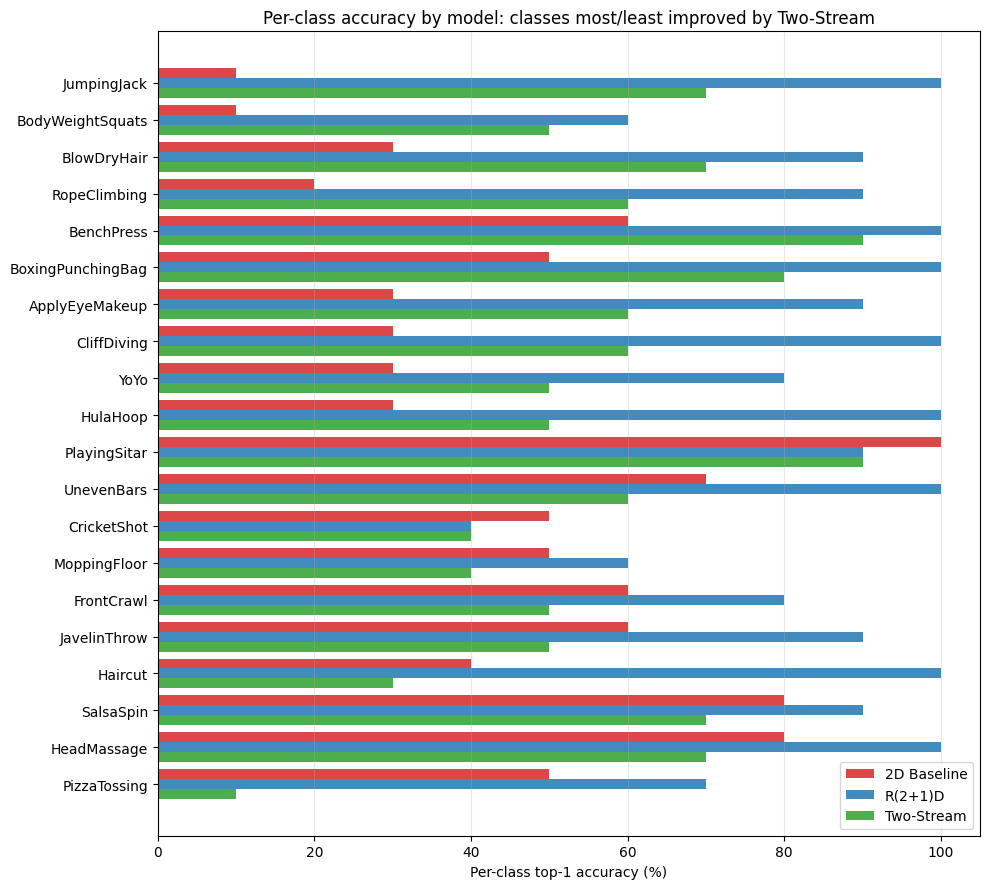

Saved: /Users/sikanderraheem/Documents/VideoActionRecognition/outputs/figures/three_model_per_class.png


In [ ]:
# Final figure: three-model comparison bar chart for top-improved and worst classes
top_imp = df_all.head(10)
top_hurt = df_all.tail(10)
focus = pd.concat([top_imp, top_hurt])

fig, ax = plt.subplots(figsize=(10, 9))
n = len(focus)
y = np.arange(n)[::-1]
width = 0.27
ax.barh(y + width,  focus['top1_2d']        * 100, width, label='2D Baseline',     color='C3', alpha=0.85)
ax.barh(y,          focus['top1_r2d']       * 100, width, label='R(2+1)D',         color='C0', alpha=0.85)
ax.barh(y - width,  focus['top1_twostream'] * 100, width, label='Two-Stream',      color='C2', alpha=0.85)
ax.set_yticks(y); ax.set_yticklabels(focus['class'])
ax.set_xlabel('Per-class top-1 accuracy (%)')
ax.set_title('Per-class accuracy by model: classes most/least improved by Two-Stream')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/three_model_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', f'{FIGURES_DIR}/three_model_per_class.png')

## Download outputs

In [ ]:
# Local mode: outputs are already on disk at OUTPUT_DIR.
print(f'All outputs saved locally at: {OUTPUT_DIR}')
print('Done.')

All outputs saved locally at: /Users/sikanderraheem/Documents/VideoActionRecognition/outputs
Done.
